In [16]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt


In [2]:
Image_Size = 256 
Batch_Size = 32
Channels = 3

In [3]:
import tensorflow as tf 
from tensorflow.keras import layers ,models

c:\Users\Piyush Singh\anaconda3\envs\myenv2\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.18) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [4]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "Plant_Dataset",
    shuffle ="True",
    image_size = (Image_Size , Image_Size),
    batch_size = (Batch_Size)
)

Found 16011 files belonging to 10 classes.


In [5]:
class_names = dataset.class_names
class_names

['Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [22]:
print(class_names)

['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


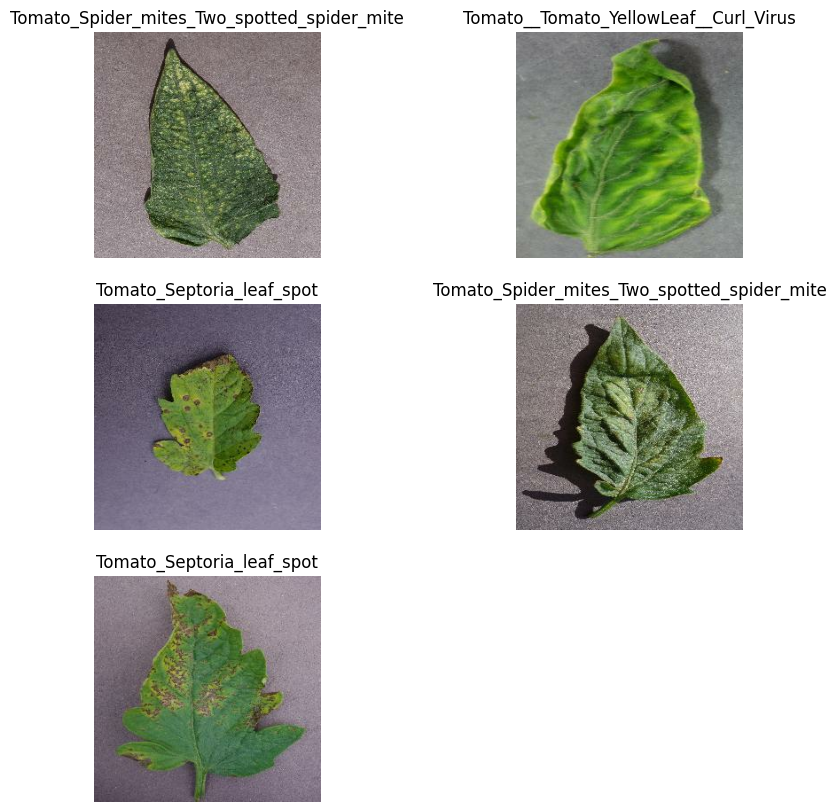

In [6]:
plt.figure(figsize=(10,10))
for image_batch , layer_batch in dataset.take(1):
    for i in range(5):
        ax = plt.subplot(3,2,i+1)
        plt.title(class_names[layer_batch[i]])
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis("off")

In [7]:
def train_test_split(dataset , train_split = 0.8 , val_split = 0.1 , test_split = 0.1 , shuffle =True , shuffle_size = 1000):
    assert(train_split+test_split+val_split)==1
    ds_size = len(dataset)
    if shuffle : 
        ds =  dataset.shuffle(shuffle_size ,seed=12)
        
    train_size = int(ds_size*train_split)
    val_size = int(ds_size*val_split)
    
    train_ds = dataset.take(train_size)
    val_ds = dataset.skip(train_size).take(val_size)
    test_ds = dataset.skip(train_size+val_size)
    return train_ds , val_ds , test_ds 

In [8]:
train_ds , val_ds , test_ds = train_test_split(dataset)


In [9]:
len(train_ds)

400

In [10]:
len(test_ds)

51

In [11]:
len(val_ds)

50

In [12]:
len(dataset)

501

In [13]:
Autotune = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(Autotune)
val_ds = val_ds.cache().prefetch(Autotune)
test_ds = test_ds.cache().prefetch(Autotune)


In [14]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(Image_Size, Image_Size),
    layers.Rescaling(1./255)
])

In [15]:
data_agumentaion = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [34]:
input_shape = (Batch_Size, Image_Size, Image_Size, Channels)
n_classes = 10

model = models.Sequential([
    resize_and_rescale,

    layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

c:\Users\Piyush Singh\anaconda3\envs\myenv2\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (32, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 10)               │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,202 (719.54 KB)

 Trainable params: 184,202 (719.54 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(
    
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics =['accuracy']
)

In [37]:
len(class_names)

10

In [38]:
model.fit(
    train_ds,
    epochs = 50,
    batch_size = Batch_Size,
    verbose = 1 ,
    validation_data =val_ds
)

Epoch 1/50


400/400 ━━━━━━━━━━━━━━━━━━━━ 376s 930ms/step - accuracy: 0.2223 - loss: 2.0929 - val_accuracy: 0.4906 - val_loss: 1.5280
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 362s 905ms/step - accuracy: 0.4897 - loss: 1.4710 - val_accuracy: 0.6388 - val_loss: 1.0748
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 361s 901ms/step - accuracy: 0.6527 - loss: 1.0257 - val_accuracy: 0.6950 - val_loss: 0.8773
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 351s 879ms/step - accuracy: 0.7141 - loss: 0.8481 - val_accuracy: 0.7688 - val_loss: 0.6626
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 355s 888ms/step - accuracy: 0.7483 - loss: 0.7407 - val_accuracy: 0.8194 - val_loss: 0.5205
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 770s 2s/step - accuracy: 0.7768 - loss: 0.6474 - val_accuracy: 0.8150 - val_loss: 0.5004
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 425s 1s/step - accuracy: 0.8023 - loss: 0.5939 - val_accuracy: 0.7875 - val_loss: 0.5291
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 362s 904ms/step - accuracy: 0.8262 - loss: 0.5104 - v

In [39]:
import os

os.makedirs("models", exist_ok=True)

model.save("models/tomato_model.keras")

In [40]:

model.save("./tomatos.h5")

In [19]:
from tensorflow.keras.models import load_model

model = load_model("tomatos.h5")   # or model.h5

In [20]:


def predict(model, img):
    img_array = np.expand_dims(img, axis=0)  # (1, H, W, C)

    predictions = model.predict(img_array, verbose=0)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)

    return predicted_class, confidence

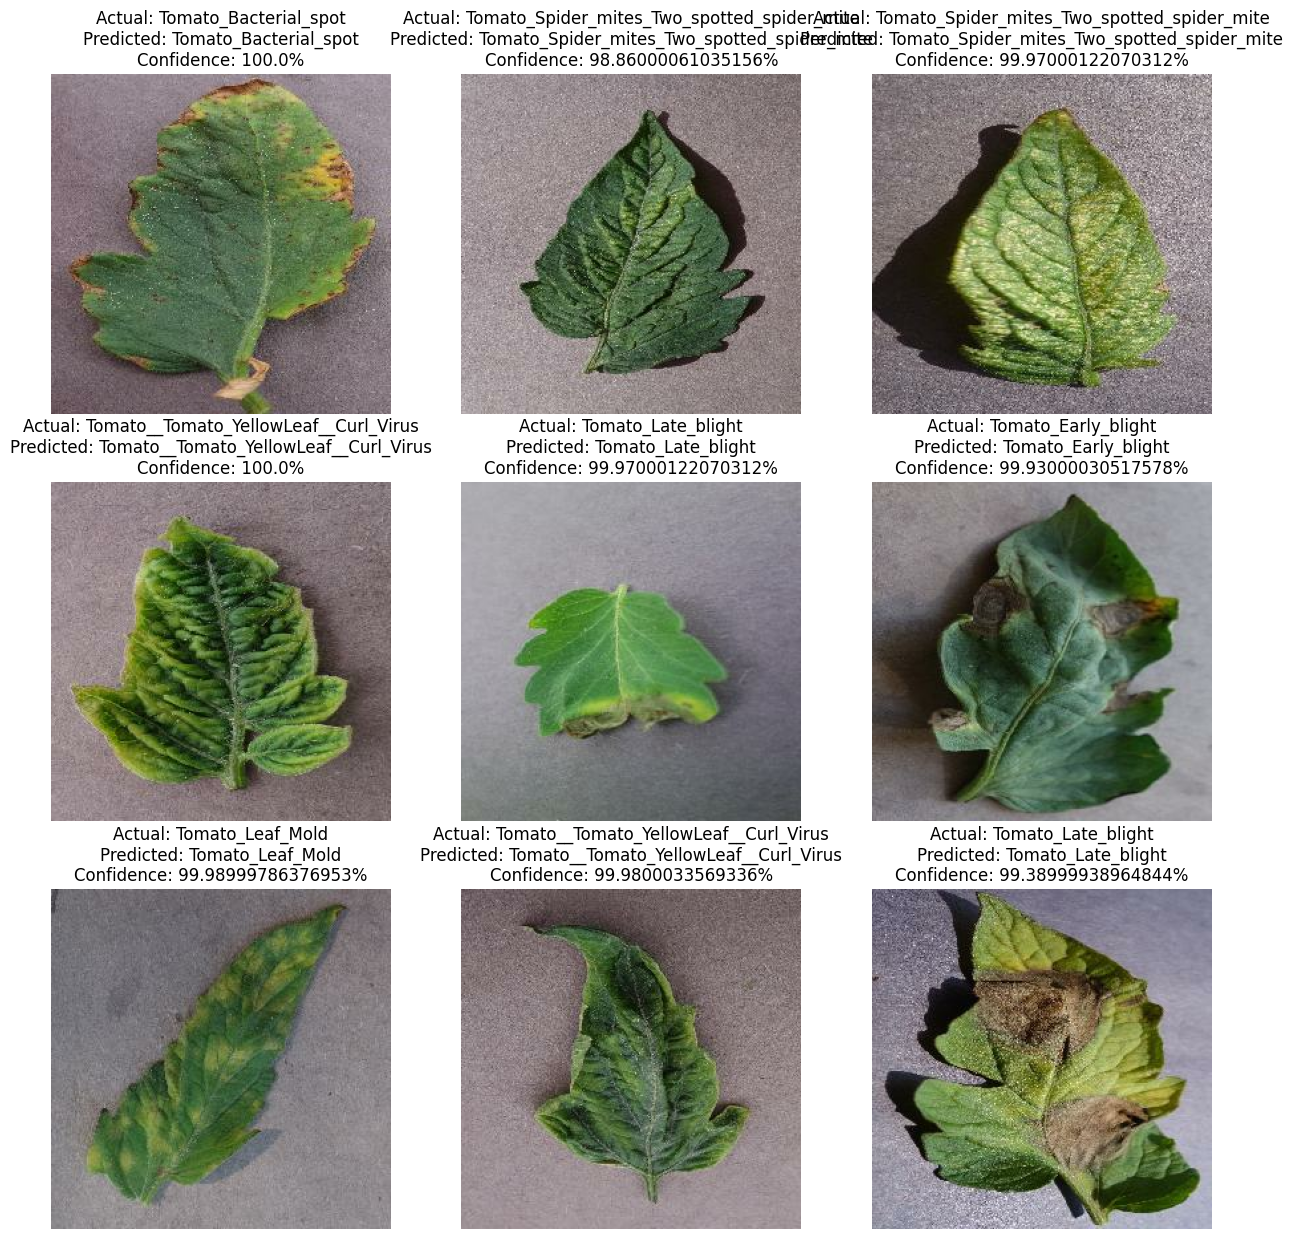

In [21]:
plt.figure(figsize=(15,15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(
            f"Actual: {actual_class}\n"
            f"Predicted: {predicted_class}\n"
            f"Confidence: {confidence}%"
        )
        plt.axis("off")